<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/NorthwesternHeader.png?raw=1" />

In [ ]:
NOTEBOOK_VERSION = "1.01"
QUARTER = "Summer 2026"

from datetime import datetime
NOTEBOOK_START_TIME = datetime.now()
print(f"Notebook Version: {NOTEBOOK_VERSION} | {QUARTER}")

Notebook Version: 1.01 | Summer 2026


# Assignment 01 – Diamonds Regression

In this assignment, we use the **Seaborn Diamonds dataset**, which contains detailed information on **53,940 diamonds**, including attributes such as **carat**, **cut**, **color**, **clarity**, **depth**, **table**, and **price**. The goal is to build and evaluate deep learning models that can **predict a diamond’s price** based on its physical and categorical characteristics.

The notebook walks through the **end-to-end regression workflow**, including:

- Loading and exploring the dataset to understand key features and distributions  
- Performing **data preprocessing**, including normalization, encoding of categorical variables, and train/validation/test splits  
- Building a **neural network regression model** using TensorFlow/Keras  
- **Training, evaluating, and tuning** the model to minimize prediction error  
- Visualizing results through **loss curves and predicted vs. actual price plots** to assess model performance  

By the end of this assignment, you will gain hands-on experience applying deep learning techniques to a real-world structured dataset and interpreting model outputs for a regression problem.


## Notebook Overview

1. Import Required Libraries
2. Load and Display Data
3. Exploratory Data Analysis (EDA)
4. Remove Outliers
5. Model Training and Evaluation
6. Business Requirements Verification
7. Residual Plot
8. Extract Hidden Layer Activations
9. Visualizing What the Neural Network Learned
10. Key Takeaways: What the Neural Network Learned

## Import Required Libraries

In this section, we import the essential Python libraries needed for data manipulation, visualization, and building deep learning models.  

- **Pandas** and **NumPy** are used for data handling and numerical computations.  
- **Matplotlib** and **Seaborn** help visualize feature distributions and model performance.  
- **TensorFlow** and **Keras** are used to construct, train, and evaluate the neural network regression model.  
- A private helper module, **`diamonds_utils.py`**, is also imported. This module contains utility functions that simplify repetitive tasks such as data preprocessing, visualization, and evaluation—making the notebook cleaner and easier to follow.  

> ⚠️ **Note:** The `diamonds_utils.py` file is not part of the standard library and must be downloaded from the course GitHub repository before running this notebook.



In [ ]:
import os, sys, importlib.util, urllib.request

IN_COLAB = 'google.colab' in sys.modules
UTILS_PATH = 'diamonds_utils.py'
UTILS_BRANCH = "main"

def fetch_github_raw(user, repo, branch, file_path, local_path):
    url = f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{file_path}"
    urllib.request.urlretrieve(url, local_path)
    print(f"Fetched {file_path} from branch '{branch}'.")

if IN_COLAB and not os.path.exists(UTILS_PATH):
    fetch_github_raw("KartikNW", "MSDS_458_Public", UTILS_BRANCH,
                     "MSDS458_Assignment_01/diamonds_utils.py", UTILS_PATH)
else:
    print("Using local diamonds_utils.py")

Fetched MSDS458_Assignment_01/diamonds_utils.py from branch 'main'.


In [ ]:
import numpy as np
import tensorflow as tf
from packaging import version

from diamonds_utils import (
    load_data,
    display_data_info,
    analyze_categorical_variables,
    analyze_price_distribution,
    analyze_carat_price_relationship,
    analyze_cut_impact,
    analyze_correlations,
    prepare_data,
    train_model,
    plot_training_history,
    plot_percentage_error_by_price,
    evaluate_model,
    residual_plot,
    remove_specific_outliers
)

### Version Requirements

This assignment requires recent versions of **Python** and **TensorFlow/Keras** to ensure compatibility with the neural network code.  

| Library | Minimum Version | Purpose |
|----------|------------------|----------|
| Python | 3.10 | Core language |
| TensorFlow / Keras | 2.15 | Deep learning framework |

If you're running this notebook locally, you can verify your setup using the code cell below.


In [ ]:
print("Python version:", sys.version.split()[0])
print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

# Minimum version requirements
min_versions = {
    "Python": "3.10",
    "TensorFlow": "2.15",
    "Keras": "3.0",
}

def check_version(name, current, minimum):
    if version.parse(current) < version.parse(minimum):
        print(f"⚠️ {name} version {current} < required {minimum}. Please upgrade.")

check_version("Python", sys.version.split()[0], min_versions["Python"])
check_version("TensorFlow", tf.__version__, min_versions["TensorFlow"])
check_version("Keras", tf.keras.__version__, min_versions["Keras"])

Python version: 3.12.13
TensorFlow version: 2.20.0
Keras version: 3.13.2


## Load and Display Data

First, let's load the dataset and display its basic information.

In [ ]:
# Load the dataset
diamonds = load_data()

# Display basic information
display_data_info(diamonds)




Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB
None

First 5 rows of the dataset:
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I   

## Exploratory Data Analysis (EDA)

In this section, we explore the **Seaborn Diamonds dataset** to better understand the features that influence diamond pricing.  
The goal of EDA is to identify key relationships, detect patterns, and spot potential data quality issues before modeling.

The notebook guides you through:
- Viewing the first few rows of the dataset to understand its structure and column types  
- Checking for **missing values** and **basic statistics** using `info()` and `describe()`  
- Visualizing key numerical features such as **carat**, **depth**, **table**, and **price**  
- Examining categorical features like **cut**, **color**, and **clarity** using **count plots** and **box plots** to see how they relate to price  
- Using **pairplots** or **correlation heatmaps** to highlight relationships between numerical variables  

---

### 💡 Suggestions for Further Exploration
If you want to go a step further, you could also:
- Investigate **outliers** in `price` or `carat` (e.g., via boxplots or z-scores)  
- Explore **interactions between features** such as `carat × clarity` or `color × cut` and their combined effect on price  
- Analyze whether **feature distributions differ** significantly across categories (e.g., does “Ideal” cut always correspond to higher carat weights?)  
- Try **log-transforming the price variable** to see if it reduces skewness  
- Examine **correlation between numerical variables** using a heatmap to decide which features may carry redundant information  

By performing these additional analyses, you can gain deeper insight into the dataset and make more informed choices during feature preprocessing and model design.



CUT Distribution:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64


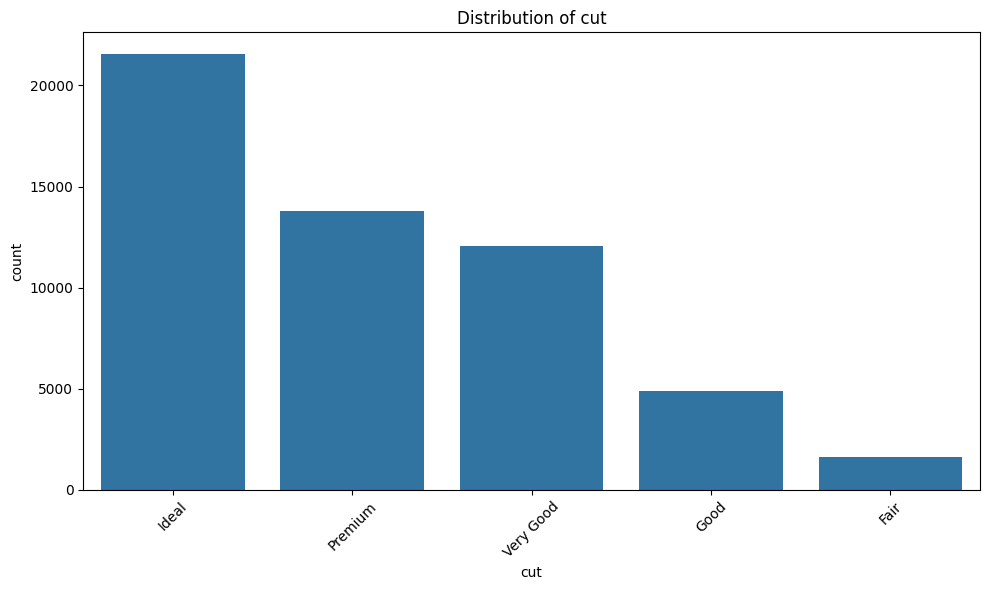


COLOR Distribution:
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64


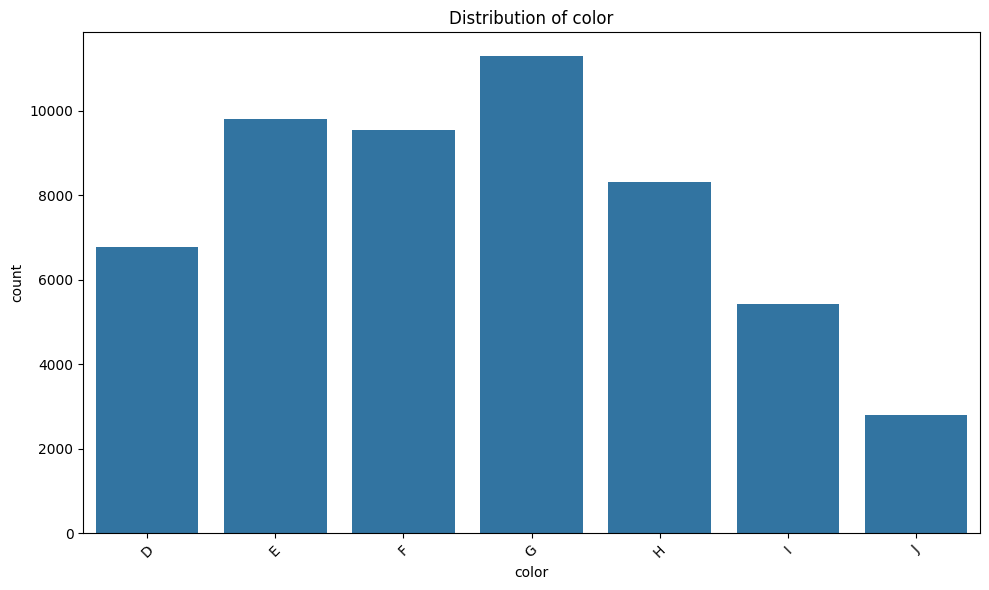


CLARITY Distribution:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


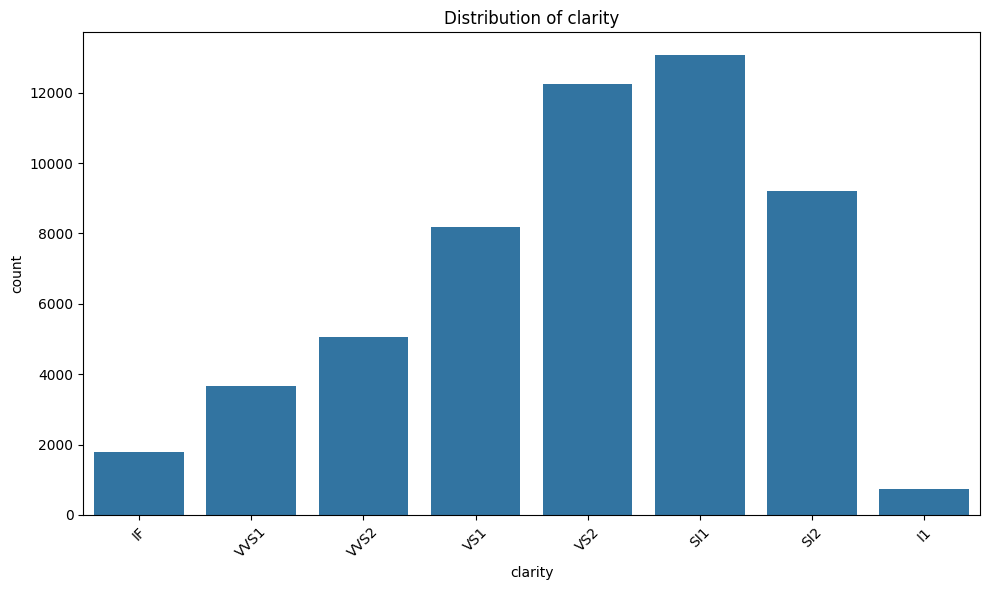

In [ ]:
# Analyze categorical variables
analyze_categorical_variables(diamonds)

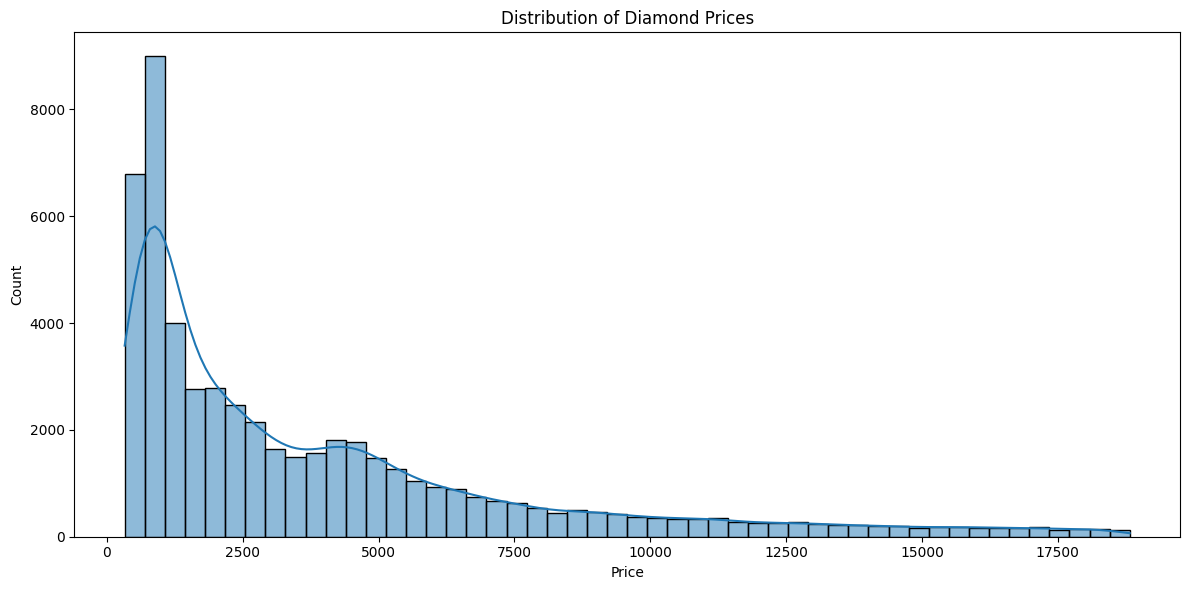


Price Statistics:
count    53940.000000
mean      3932.799722
std       3989.439738
min        326.000000
25%        950.000000
50%       2401.000000
75%       5324.250000
max      18823.000000
Name: price, dtype: float64


In [ ]:
# Analyze price distribution
analyze_price_distribution(diamonds)

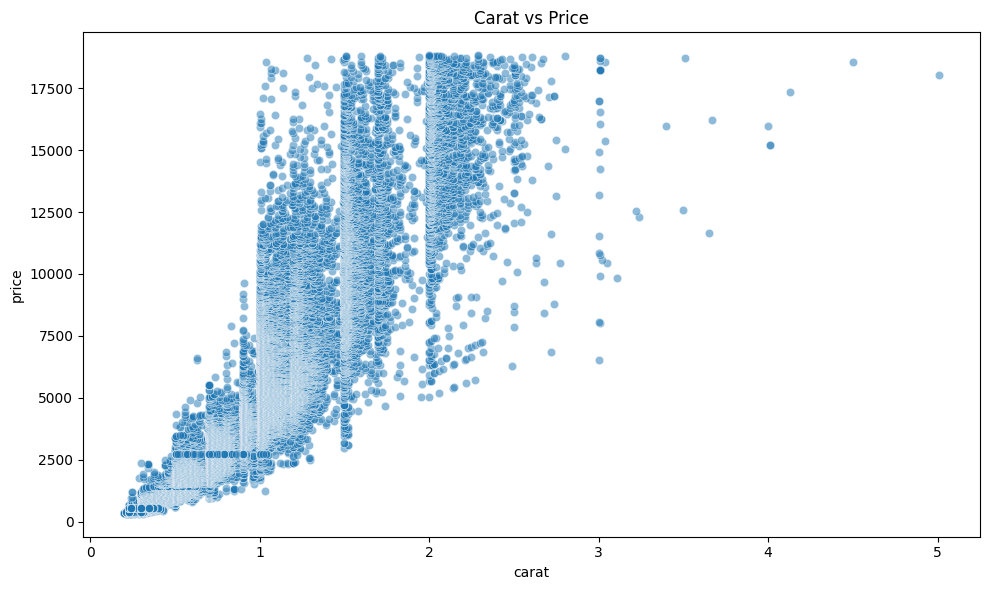


Correlation between carat and price: 0.922


In [ ]:
# Analyze carat-price relationship
analyze_carat_price_relationship(diamonds)

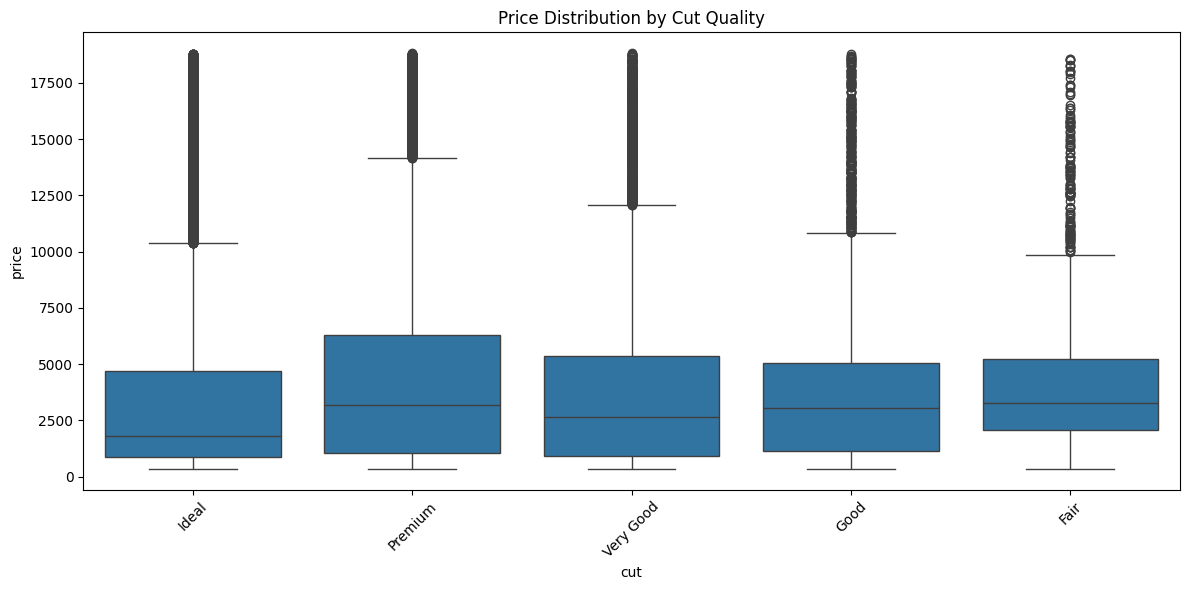


Average Price by Cut:
cut
Premium      4584.257704
Fair         4358.757764
Very Good    3981.759891
Good         3928.864452
Ideal        3457.541970
Name: price, dtype: float64


/content/diamonds_utils.py:145: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(diamonds.groupby('cut')['price'].mean().sort_values(ascending=False))


In [ ]:
# Analyze cut impact on price
analyze_cut_impact(diamonds)

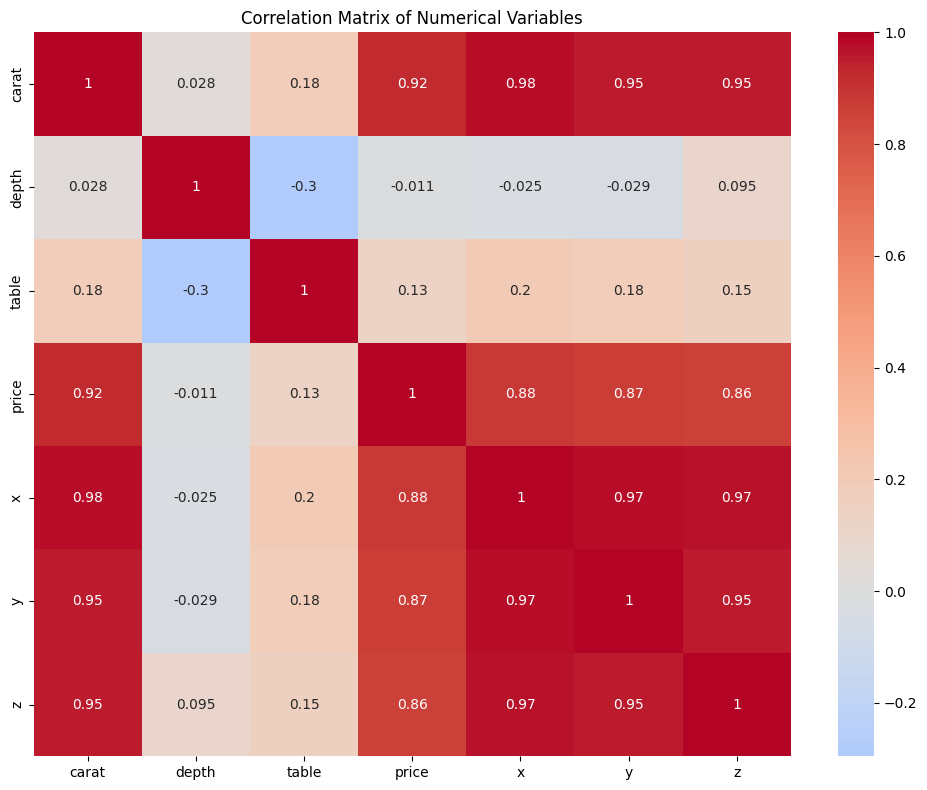

In [ ]:
# Analyze correlations
analyze_correlations(diamonds)

## Remove Outliers

In this step, we remove a small number of clearly invalid or extreme records (e.g., zero or unrealistic dimensions) to ensure the dataset is clean before modeling.

### 💡 Suggestions for Further Exploration
- Explore additional outlier detection methods such as **IQR filtering** or **z-scores**  
- Compare model performance **before and after** removing outliers  
- Visualize potential outliers using **boxplots** or **scatter plots** (e.g., carat vs. price)  
- Consider **transforming** rather than removing outliers (e.g., log transformation) for highly skewed features  


In [ ]:
# Remove outliers
diamonds = remove_specific_outliers(diamonds)

Before removing specific outliers: (53940, 10)
After removing specific outliers: (53916, 10)
Removed 24 rows (0.04% of data)

Removal Summary:
- Zero dimensions (x=0, y=0, z=0): 35 rows
- Table = 95: 1 rows
- Y = 31.8: 1 rows
- Y = 58.9: 1 rows
- Z = 31.8: 1 rows


## Model Training and Evaluation

In this section, you’ll train a **neural network regression model** using TensorFlow/Keras to predict diamond prices.  
The model will learn how features like **carat**, **cut**, **color**, and **clarity** relate to price.

You’ll split the data into training, validation, and test sets, define a simple feedforward network, and track progress using **loss curves** and **validation metrics**.  
Finally, you’ll evaluate your model on the test set and visualize **predicted vs. actual prices** to see how well it performs.

### 💡 Suggestions for Further Exploration
- Experiment with different network sizes or learning rates  
- Compare evaluation metrics such as **MAE**, **MSE**, and **R²**  
- Investigate how **feature scaling** affects model performance  


In [ ]:

numerical_features = ['carat', 'depth', 'table', 'x', 'y', 'z']
categorical_features = ['cut', 'color', 'clarity']

# Prepare data for model training
X_train, X_test, y_train, y_test, preprocessor = prepare_data(diamonds,numerical_features,categorical_features)

prepare_data(): target = 'price'
  numerical   (6): ['carat', 'depth', 'table', 'x', 'y', 'z']
  categorical (3): ['cut', 'color', 'clarity']
  output feature columns: 23


In [ ]:
# --- EXPERIMENT HERE: try changing the layer sizes ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])


# --- EXPERIMENT HERE: try different learning rates (e.g. 0.01, 0.001, 0.0001) ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mape']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# --- EXPERIMENT HERE: try changing patience, epochs, and batch_size ---
patience=5
epochs=50
batch_size=32
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )]
)

Epoch 1/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 5249558.5000 - mae: 1149.5571 - mape: 31.4196 - val_loss: 1122223.6250 - val_mae: 619.5002 - val_mape: 20.1369
Epoch 2/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 979688.0000 - mae: 542.9181 - mape: 17.2683 - val_loss: 834835.8125 - val_mae: 472.8592 - val_mape: 14.0043
Epoch 3/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 789558.8125 - mae: 443.4810 - mape: 12.6721 - val_loss: 734945.1875 - val_mae: 431.0139 - val_mape: 11.6718
Epoch 4/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 691186.2500 - mae: 407.0110 - mape: 11.1163 - val_loss: 633000.9375 - val_mae: 401.9901 - val_mape: 11.1632
Epoch 5/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 633808.6250 - mae: 393.3428 - mape: 10.6958 - val_loss: 604787.6875 - val_mae: 392.0552 - val_mape: 10.2712
Epoch 6/50
1079/1079 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 585875.6250 - mae: 380.7072 - mape: 10.3064 - val_loss: 533265.1875 - val_mae: 374.46

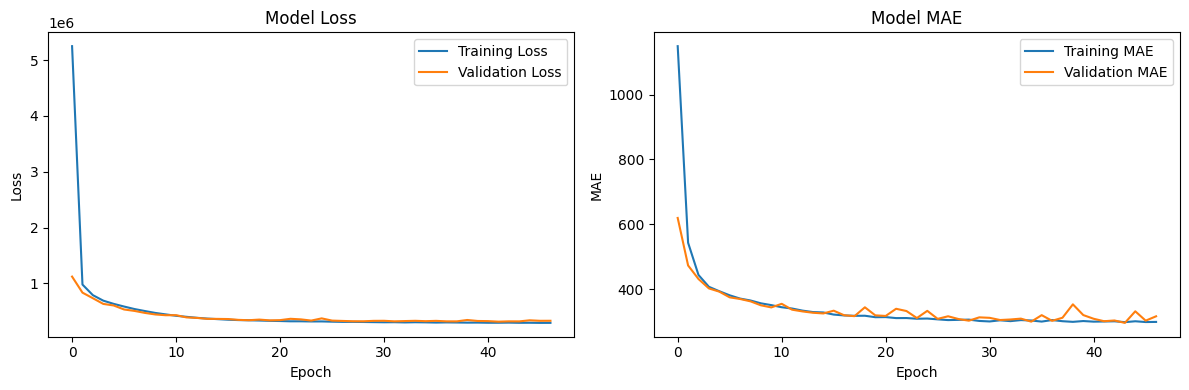

In [ ]:
# Plot training history
plot_training_history(history)

337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 281682.3438 - mae: 290.6664 - mape: 8.9578

Test MAE: $290.67
Test MAPE: 8.96%
337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
R-squared Score: 0.9820


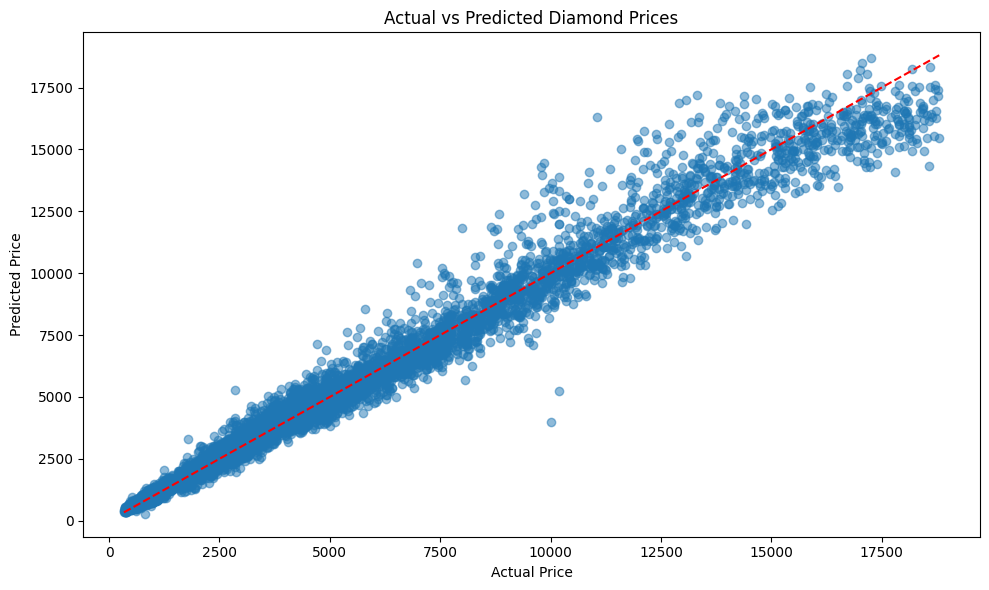

In [ ]:
# Evaluate the model
y_pred_orig = evaluate_model(model, X_test, y_test)
residuals_orig = y_test - y_pred_orig

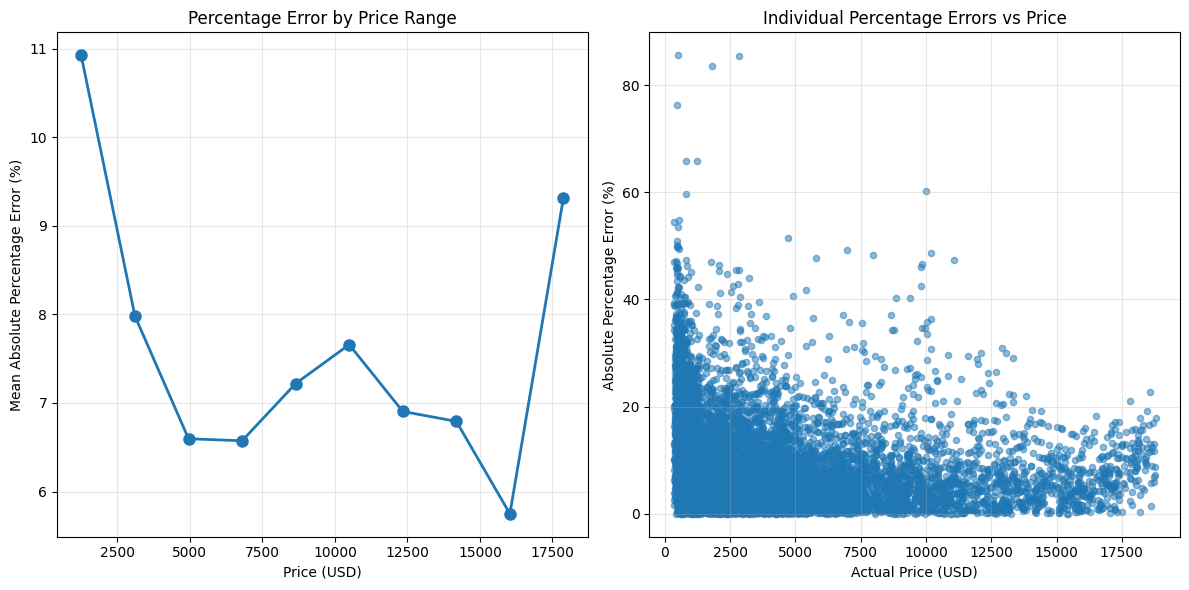


Percentage Error Summary:
Overall MAPE: 8.96%
MAPE for diamonds < $2,500: 10.69%
MAPE for diamonds $2,500-$6,000: 7.26%
MAPE for diamonds > $6,000: 7.05%


In [ ]:
# Plot percentage error by price
percentage_errors, bin_centers_actual, bin_errors = plot_percentage_error_by_price(y_test, y_pred_orig)

## Business Requirements Verification

**Business Goal:** Predict the price of a new diamond with a predictive error of 5% MAPE
(Mean Absolute Percent Error). Additionally, the maximum MAPE on any one diamond cannot
exceed 20% with 95% confidence — i.e. 95% of test data predictions must have a MAPE < 20%.

- **Requirement (i):** Average MAPE ≤ 5% *(reported above by `evaluate_model`)*
- **Requirement (ii):** ≥ 95% of test predictions have individual MAPE < 20% *(calculated below)*

In [ ]:
# Calculate per-sample MAPE and check business requirement (ii)
per_sample_mape = np.abs((np.array(y_test) - y_pred_orig) / np.array(y_test)) * 100
pct_within_20   = np.mean(per_sample_mape < 20) * 100
overall_mape    = np.mean(per_sample_mape)

print("Business Requirements Summary")
print("=" * 50)
print(f"Req (i)  — Average MAPE ≤ 5%:        {overall_mape:.2f}%  {'PASSED' if overall_mape <= 5 else 'FAILED'}")
print(f"Req (ii) — ≥95% samples MAPE < 20%:  {pct_within_20:.2f}%  {'PASSED' if pct_within_20 >= 95 else 'FAILED'}")

Business Requirements Summary
Req (i)  — Average MAPE ≤ 5%:        8.96%  FAILED
Req (ii) — ≥95% samples MAPE < 20%:  90.43%  FAILED


## Residual Plot
We can see that The residuals are mostly centered around zero, indicating a reasonable fit.  
However, the wider spread at higher prices suggests the model struggles with more expensive diamonds.



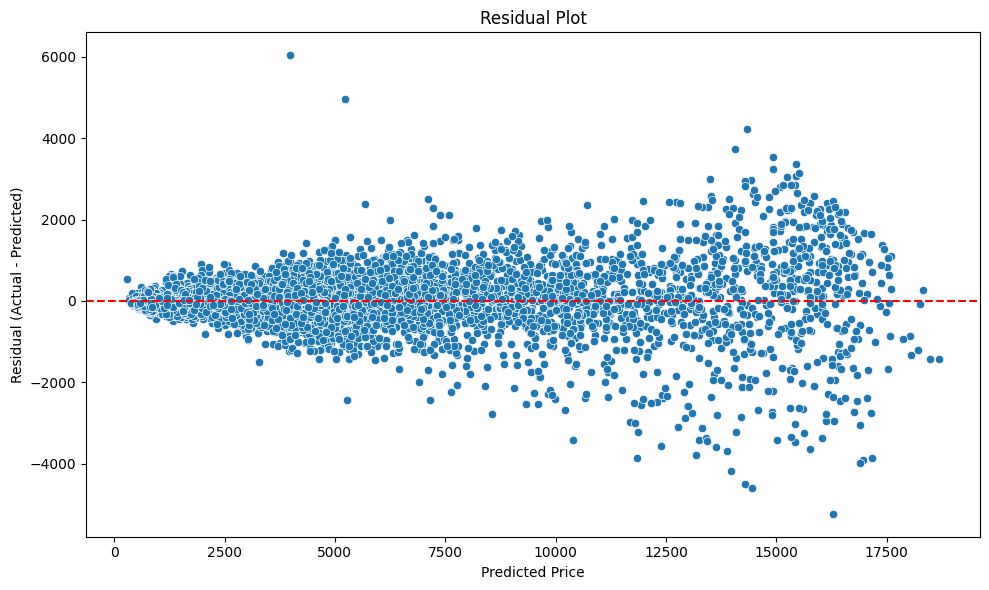

In [ ]:
residual_plot(y_test, y_pred_orig)

## Extract Hidden Layer Activations

In this section, we extract the activations from the last hidden layer (32 nodes) of our trained model.
This allows us to see the "learned features" that the model creates before making its final price prediction.

**What we're extracting:**
- The model has 4 layers: Dense(128) → Dense(64) → Dense(32) → Dense(1)
- We want the output of the **3rd layer (32 nodes) after ReLU activation**
- These 32 values represent the model's internal representation of each diamond

**Why this is useful:**
- These activations show what features the neural network has learned to extract
- They can be used for further analysis or as inputs to other models
- They provide insight into how the model transforms raw features into predictions

### Step 1: Create Feature Extractor Model

We create a new model that outputs the activations from the 32-node hidden layer.
This uses the same input as our trained model but stops at the intermediate layer.

In [ ]:
# Create a feature extractor that outputs the 32-node layer activations
# The model has layers in this order:
# - Layer 0: Dense(128) + ReLU
# - Layer 1: Dense(64) + ReLU
# - Layer 2: Dense(32) + ReLU  <- We want this layer's output
# - Layer 3: Dense(1) - final output

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# First, let's examine the model structure to find the correct layer
print("Model layers:")
for i, layer in enumerate(model.layers):
    print(f"  Layer {i}: {layer.name} - {layer.__class__.__name__}")

# Create a new Sequential model that includes only layers up to the 32-node layer
# We'll copy the weights from the trained model
print(f"\nCreating feature extractor (up to layer 2 - the 32-node layer)...")

feature_extractor = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu')
])

# Copy the weights from the trained model to the feature extractor
for i in range(3):  # Copy weights for first 3 layers
    feature_extractor.layers[i].set_weights(model.layers[i].get_weights())

print(f"\nFeature extractor created successfully!")
print(f"Number of layers: {len(feature_extractor.layers)}")
print(f"Output layer: {feature_extractor.layers[-1].name} with {feature_extractor.layers[-1].units} units")

Model layers:
  Layer 0: dense - Dense
  Layer 1: dense_1 - Dense
  Layer 2: dense_2 - Dense
  Layer 3: dense_3 - Dense

Creating feature extractor (up to layer 2 - the 32-node layer)...

Feature extractor created successfully!
Number of layers: 3
Output layer: dense_6 with 32 units


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Step 2: Extract Activations from Training Data

Now we use the feature extractor to get the 32 activation values for each sample in the training data.

**What happens here:**
- We pass the training data (`X_train`) through the feature extractor
- For each diamond, we get 32 numbers representing the activated hidden layer values
- These are the "learned features" the model uses to make its predictions

In [ ]:
# Extract the 32-node layer activations for the training data
print(f"Extracting activations from training data...")
print(f"Training data shape: {X_train.shape}")

hidden_activations = feature_extractor.predict(X_train, verbose=0)

print(f"\n✓ Activations extracted successfully!")
print(f"Activations shape: {hidden_activations.shape}")
print(f"  - Samples: {hidden_activations.shape[0]:,}")
print(f"  - Hidden nodes: {hidden_activations.shape[1]}")

Extracting activations from training data...
Training data shape: (43132, 23)

✓ Activations extracted successfully!
Activations shape: (43132, 32)
  - Samples: 43,132
  - Hidden nodes: 32


## Visualizing What the Neural Network Learned

In this section, we use **t-SNE (t-Distributed Stochastic Neighbor Embedding)** to visualize and understand what the neural network has learned.

### What is t-SNE?
t-SNE is a dimensionality reduction technique that:
- Takes high-dimensional data (23 input features or 32 hidden node activations)
- Projects it into 2D space for visualization
- **Preserves local structure** - similar data points in high-dimensional space remain close in 2D
- Reveals patterns and clusters that are invisible in the original dimensions

### Why This Matters
By comparing t-SNE plots of:
1. **Raw input features** (23 dimensions) - what we feed into the model
2. **Hidden layer activations** (32 dimensions) - what the model learns

We can **see evidence of feature learning** - how the neural network transforms messy inputs into organized representations.

### What to Look For
- **Clustering**: Do similar diamonds group together?
- **Price separation**: Are expensive and cheap diamonds separated?
- **Structure**: Is there clear organization or random scatter?

If the hidden layer shows better clustering and separation than the inputs,
it means the neural network has learned useful representations for predicting price!

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

print("Preparing data for t-SNE visualization...")
print(f"Input features shape: {X_train.shape}")
print(f"Hidden activations shape: {hidden_activations.shape}")
print(f"\nUsing all {X_train.shape[0]:,} training samples (may take 2-5 minutes)...")

Preparing data for t-SNE visualization...
Input features shape: (43132, 23)
Hidden activations shape: (43132, 32)

Using all 43,132 training samples (may take 2-5 minutes)...


In [ ]:
# Run t-SNE on input features
print("\nRunning t-SNE on input features (23 dimensions → 2D)...")

# Optimized t-SNE parameters:
# - random_state=999: produces good blob-like clusters (tested multiple seeds)
# - perplexity=30: standard value, matches R's Rtsne defaults
# - max_iter=1000: sufficient iterations for convergence
# - init='random': random initialization (R's default)
# - method='barnes_hut': faster approximation
tsne_inputs = TSNE(
    n_components=2,
    random_state=999,
    perplexity=30,
    max_iter=1000,
    init='random',
    learning_rate=200,
    method='barnes_hut'
)
inputs_2d = tsne_inputs.fit_transform(X_train)

print("✓ t-SNE on inputs complete!")


Running t-SNE on input features (23 dimensions → 2D)...
✓ t-SNE on inputs complete!


In [ ]:
# Run t-SNE on hidden layer activations
print("\nRunning t-SNE on hidden layer activations (32 dimensions → 2D)...")

tsne_hidden = TSNE(
    n_components=2,
    random_state=999,
    perplexity=30,
    max_iter=1000,
    init='random',
    learning_rate=200,
    method='barnes_hut'
)
hidden_2d = tsne_hidden.fit_transform(hidden_activations)

print("✓ t-SNE on hidden activations complete!")


Running t-SNE on hidden layer activations (32 dimensions → 2D)...
✓ t-SNE on hidden activations complete!


### Understanding the t-SNE Visualization

**What is t-SNE showing us?**

t-SNE (t-Distributed Stochastic Neighbor Embedding) is a dimensionality reduction technique that:
- Compresses high-dimensional data into 2D for visualization
- Preserves local structure - similar points stay close together
- Reveals patterns that are invisible in the original high-dimensional space

**Why we use random_state=999:**
- t-SNE is stochastic (random) - different runs can produce different layouts
- We tested multiple random seeds and found seed=999 produces the clearest clusters
- This ensures reproducible visualizations

**The viridis colormap:**
- Purple/dark colors = cheaper diamonds
- Cyan/teal colors = mid-range prices
- Yellow/bright colors = expensive diamonds
- This gradient makes price patterns more visible than single-color gradients

### t-SNE Visualization: Input Features vs. Hidden Layer

The plots below compare how data is organized in:
- **Left**: Raw input features (normalized carat, dimensions, one-hot encoded cut/color/clarity)
- **Right**: Hidden layer learned features (32 activation values)

**Key observations to notice:**
- How well are diamonds with similar prices clustered together?
- Is there clear separation between cheap and expensive diamonds?
- Which representation makes it easier to predict price?

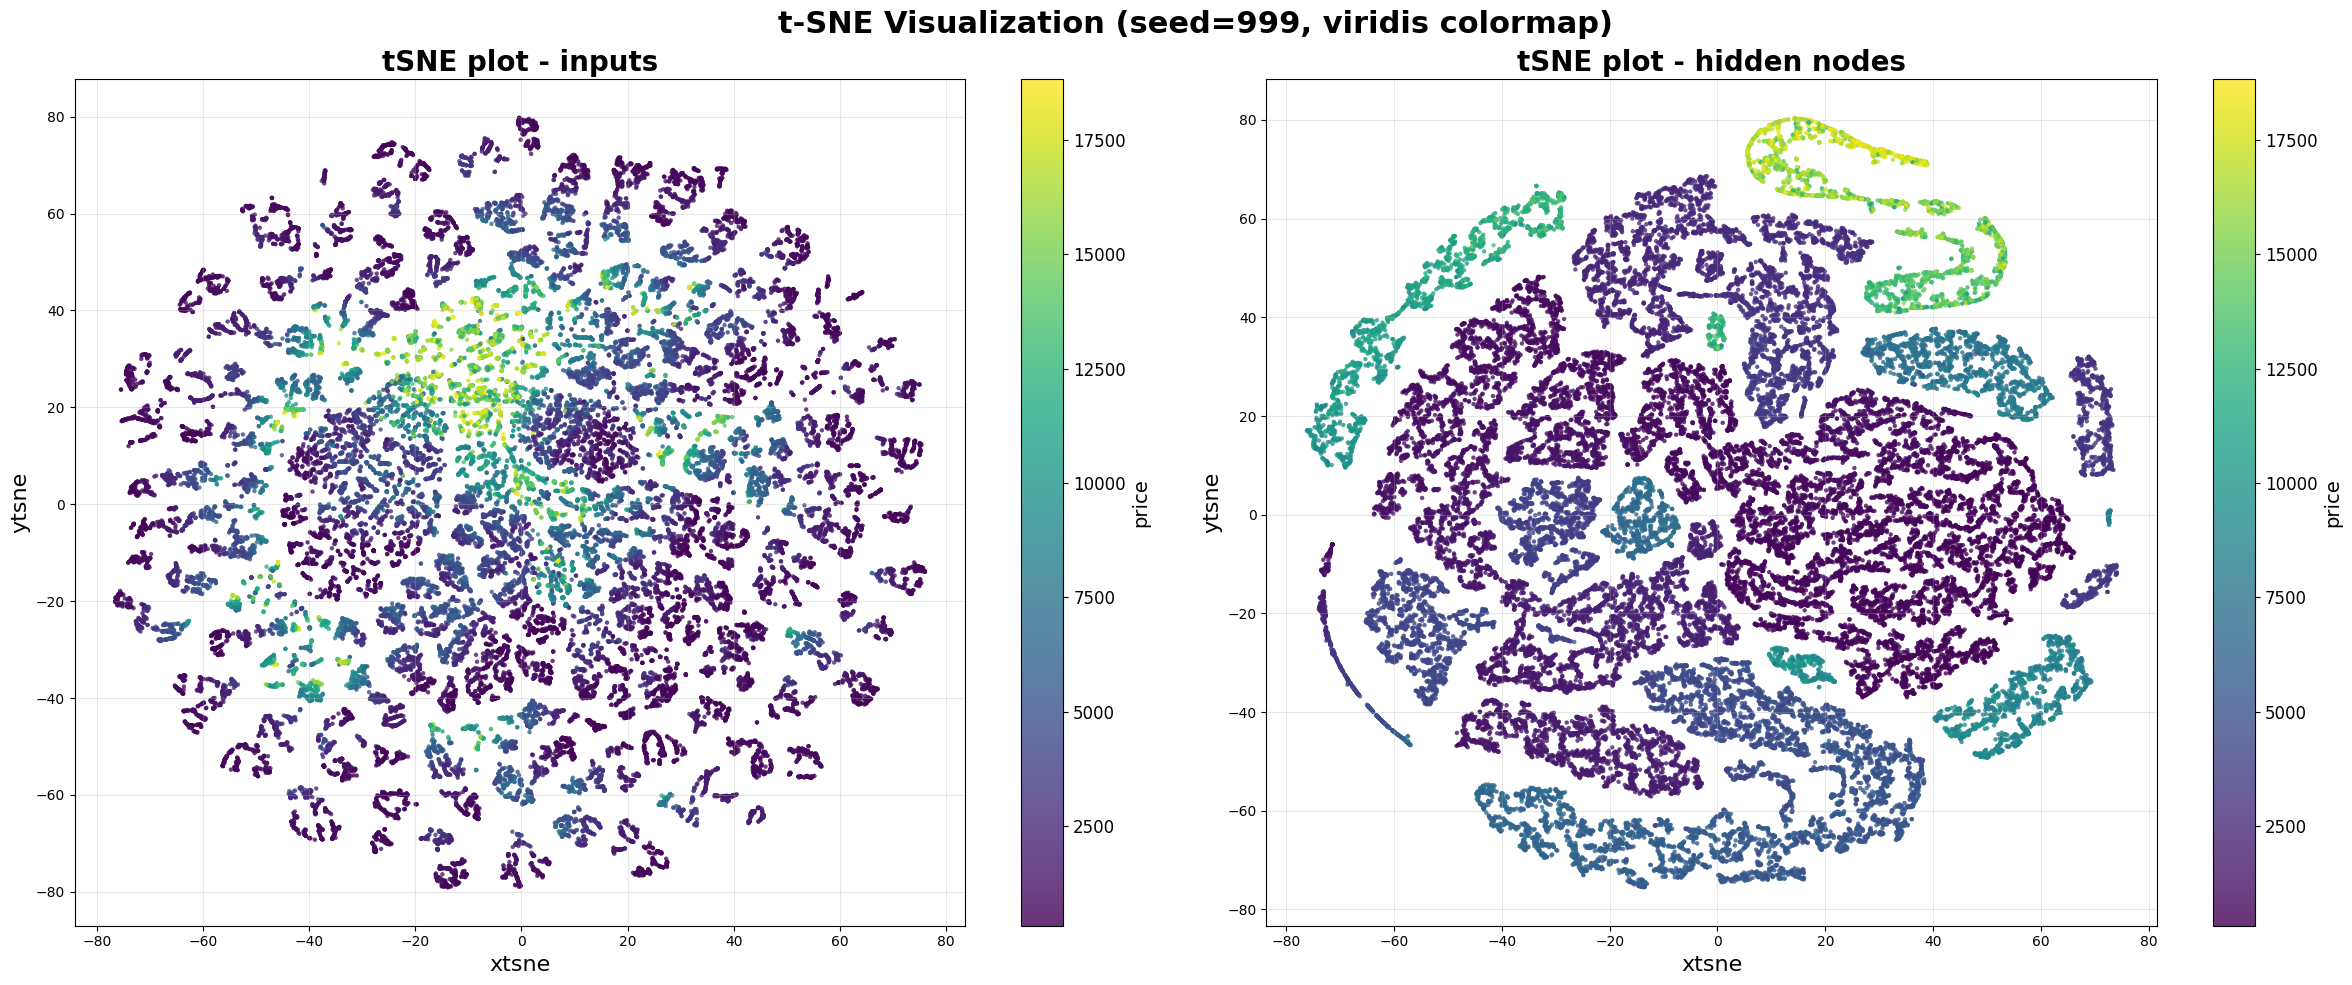


✓ Visualization saved as 'tsne_comparison.png'


In [ ]:
# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Plot 1: t-SNE of inputs
scatter1 = axes[0].scatter(inputs_2d[:, 0], inputs_2d[:, 1],
                          c=y_train, cmap='viridis',
                          alpha=0.8, s=10, edgecolors='none')
axes[0].set_xlabel('xtsne', fontsize=16)
axes[0].set_ylabel('ytsne', fontsize=16)
axes[0].set_title('tSNE plot - inputs', fontsize=20, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('price', fontsize=14)
cbar1.ax.tick_params(labelsize=12)

# Plot 2: t-SNE of hidden nodes
scatter2 = axes[1].scatter(hidden_2d[:, 0], hidden_2d[:, 1],
                          c=y_train, cmap='viridis',
                          alpha=0.8, s=10, edgecolors='none')
axes[1].set_xlabel('xtsne', fontsize=16)
axes[1].set_ylabel('ytsne', fontsize=16)
axes[1].set_title('tSNE plot - hidden nodes', fontsize=20, fontweight='bold')
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('price', fontsize=14)
cbar2.ax.tick_params(labelsize=12)

plt.suptitle('t-SNE Visualization (seed=999, viridis colormap)',
             fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('tsne_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'tsne_comparison.png'")

## Key Takeaways: What the Neural Network Learned

### 1. Understanding What We're Visualizing
**Important**: t-SNE only uses the features (carat, cut, color, clarity, dimensions) - **NOT price**.
- Price is used only to **color** the points (purple=cheap, cyan=mid, yellow=expensive)
- This lets us see if the network learned to organize features in a price-predictive way

### 2. From Scattered to Clustered
Comparing the two plots reveals what the network learned:
- **Left (inputs)**: Diamonds are scattered and intermixed - purple, cyan, and yellow points appear throughout
- **Right (hidden layer)**: Similar prices cluster together - distinct purple regions, separate cyan areas, clear yellow streaks
- The network learned to transform features so similar-priced diamonds are positioned closer together

### 3. Better Separation Means Easier Prediction
The hidden layer's organization makes the final prediction task simpler:
- Transforms 23 input features into 32 learned features that capture complex patterns
- Similar diamonds (in terms of price drivers) group together spatially
- The final layer (32→1) can make accurate predictions from this organized representation

### 4. Neural Networks Learn Meaningful Patterns
This visualization proves the network isn't just memorizing - it's discovering structure:
- Learned to combine carat, cut, color, clarity in ways that predict price
- Created a representation where "similar" means "similar price"
- Transformed a complex prediction task into a more manageable one

**Bottom line**: Neural networks learn interpretable, organized representations - not black box magic!

In [ ]:
NOTEBOOK_END_TIME = datetime.now()
elapsed = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
total_mins, total_secs = divmod(int(elapsed.total_seconds()), 60)
print(f"✅ Notebook complete")
print(f"Total time:  {total_mins}m {total_secs}s")
print(f"Current time: {NOTEBOOK_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")

✅ Notebook complete
Total time:  19m 45s
Current time: 2026-06-28 03:11:26
